# Chapter 6 Exercises
## Exercise 6.1

Pad the inputs to the maximum number of tokens the model supports and observe how it affects the predictive performance.

In [1]:
import tiktoken
from torch.utils.data import DataLoader
from gpt_2.model import GPT_CONFIG_124M
from gpt_2.classification_ft import SpamDataset

tokenizer = tiktoken.get_encoding('gpt2')

num_workers = 0
batch_size = 8

train_ds = SpamDataset(
    csv_file='./train.csv',
    tokenizer=tokenizer,
    max_length=GPT_CONFIG_124M['context_length'],
)

val_ds = SpamDataset(
    csv_file='./validation.csv',
    tokenizer=tokenizer,
    max_length=GPT_CONFIG_124M['context_length'],
)

test_ds = SpamDataset(
    csv_file='./test.csv',
    tokenizer=tokenizer,
    max_length=GPT_CONFIG_124M['context_length'],
)

train_dl = DataLoader(
    dataset=train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_dl = DataLoader(
    dataset=val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    drop_last=False,
)

test_dl = DataLoader(
    dataset=test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    drop_last=False,
)

In [2]:
from gpt_2.model import GPTModel
from gpt_2.pretrain import load_weights_into_gpt
from gpt_2.gpt_download import download_and_load_gpt2

CHOOSE_MODEL = 'gpt2-small (124M)'
INPUT_PROMPT = 'Every effort moves you'
BASE_CONFIG = {
    'vocab_size': 50257,
    'context_length': 1024,
    'drop_rate': 0.0,
    'qkv_bias': True,
}

model_configs = {
    'gpt2-small (124M)': {'emb_dim': 768, 'n_layers': 12, 'n_heads': 12,},
    'gpt2-medium (355M)': {'emb_dim': 1024, 'n_layers': 24, 'n_heads': 16,},
    'gpt2-large (774M)': {'emb_dim': 1280, 'n_layers': 36, 'n_heads': 20,},
    'gpt2-xl (1558M)': {'emb_dim': 1600, 'n_layers': 48, 'n_heads': 25,},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(' ')[-1].lstrip('(').rstrip(')')
settings, params = download_and_load_gpt2(
    model_size=model_size, models_dir='gpt2'
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


In [3]:
import torch.nn as nn
# Freeze all the weights
for p in model.parameters():
    p.requires_grad = False

num_classes = 2
# Substituite the out_head with new classification head
model.out_head = nn.Linear(
    BASE_CONFIG['emb_dim'],
    num_classes
)

# Unfreeze the last transformer block as well as the last
# LayerNorm block
for p in model.trf_blocks[-1].parameters():
    p.requires_grad = True

for p in model.final_norm.parameters():
    p.requires_grad = True

In [4]:
import time
import torch
from gpt_2.classification_ft import train_classifier_simple

start_time = time.time()
torch.manual_seed(123)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5
model.to(device)

train_losses, val_losses, train_acc, val_acc, examples_seen = \
    train_classifier_simple(
        model=model,
        train_loader=train_dl,
        val_loader=val_dl,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs,
        eval_freq=50,
        eval_iter=5,
    )

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 5.174, Val loss 4.715
Ep 1 (Step 000050): Train loss 0.696, Val loss 0.692
Ep 1 (Step 000100): Train loss 0.608, Val loss 0.652
Training accuracy: 52.50% | Validation accuracy: 52.50%
Ep 2 (Step 000150): Train loss 0.642, Val loss 0.619
Ep 2 (Step 000200): Train loss 0.604, Val loss 0.558
Ep 2 (Step 000250): Train loss 0.449, Val loss 0.506
Training accuracy: 80.00% | Validation accuracy: 92.50%
Ep 3 (Step 000300): Train loss 0.301, Val loss 0.313
Ep 3 (Step 000350): Train loss 0.222, Val loss 0.353
Training accuracy: 90.00% | Validation accuracy: 87.50%
Ep 4 (Step 000400): Train loss 0.268, Val loss 0.281
Ep 4 (Step 000450): Train loss 0.106, Val loss 0.212
Ep 4 (Step 000500): Train loss 0.154, Val loss 0.272
Training accuracy: 95.00% | Validation accuracy: 90.00%
Ep 5 (Step 000550): Train loss 0.125, Val loss 0.233
Ep 5 (Step 000600): Train loss 0.206, Val loss 0.220
Training accuracy: 97.50% | Validation accuracy: 87.50%
Training completed in 10.91 min

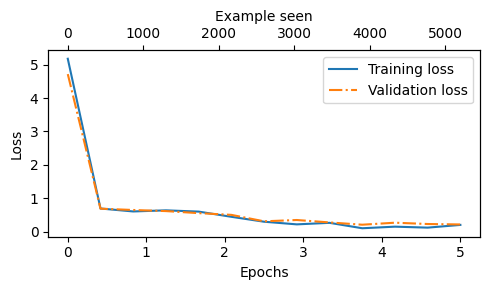

In [5]:
from gpt_2.classification_ft import plot_values

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

In [6]:
# Calculate the performance metrics across whole training, validation
# and test datasets
from gpt_2.classification_ft import calc_accuracy_loader
train_accuracy = calc_accuracy_loader(train_dl, model, device)
val_accuracy = calc_accuracy_loader(val_dl, model, device)
test_accuracy = calc_accuracy_loader(test_dl, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 93.65%
Validation accuracy: 93.29%
Test accuracy: 94.33%


In [7]:
from gpt_2.classification_ft import classify_review

text_1 = (
    "You were selected as the designed prize winner,"
    " click the link below to claim 200$ USD "
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_ds.max_length
))

text_2 = (
    "Hi Rachel, it's been a while since the last time we talked!"
    " How are you? Are you having fun in Minnesota?"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_ds.max_length
))

spam
not spam


## Exercise 6.2

Instead of fine-tuning just the final transformer block, fine-tune the entire
model and assess the effect on predictive performance.

In [8]:
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

model.out_head = nn.Linear(
    BASE_CONFIG['emb_dim'],
    num_classes
)

# Ensure all the parameters are not frozen
for p in model.parameters():
  p.requires_grad = True

In [9]:
# Rebuild the whole dataset to only use the max length of the train_ds
train_ds = SpamDataset(
    csv_file='./train.csv',
    tokenizer=tokenizer,
    max_length=None,
)

val_ds = SpamDataset(
    csv_file='./validation.csv',
    tokenizer=tokenizer,
    max_length=train_ds.max_length,
)

test_ds = SpamDataset(
    csv_file='./test.csv',
    tokenizer=tokenizer,
    max_length=train_ds.max_length,
)

train_dl = DataLoader(
    dataset=train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_dl = DataLoader(
    dataset=val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    drop_last=False,
)

test_dl = DataLoader(
    dataset=test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    drop_last=False,
)

In [10]:
# Fine-tune the whole model

start_time = time.time()
torch.manual_seed(123)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5
model.to(device)

train_losses, val_losses, train_acc, val_acc, examples_seen = \
    train_classifier_simple(
        model=model,
        train_loader=train_dl,
        val_loader=val_dl,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs,
        eval_freq=50,
        eval_iter=5,
    )

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.163, Val loss 2.495
Ep 1 (Step 000050): Train loss 0.139, Val loss 0.149
Ep 1 (Step 000100): Train loss 0.031, Val loss 0.082
Training accuracy: 100.00% | Validation accuracy: 100.00%
Ep 2 (Step 000150): Train loss 0.041, Val loss 0.098
Ep 2 (Step 000200): Train loss 0.022, Val loss 0.064
Ep 2 (Step 000250): Train loss 0.008, Val loss 0.049
Training accuracy: 97.50% | Validation accuracy: 95.00%
Ep 3 (Step 000300): Train loss 0.053, Val loss 0.046
Ep 3 (Step 000350): Train loss 0.002, Val loss 0.008
Training accuracy: 100.00% | Validation accuracy: 100.00%
Ep 4 (Step 000400): Train loss 0.005, Val loss 0.012
Ep 4 (Step 000450): Train loss 0.002, Val loss 0.009
Ep 4 (Step 000500): Train loss 0.001, Val loss 0.004
Training accuracy: 100.00% | Validation accuracy: 100.00%
Ep 5 (Step 000550): Train loss 0.000, Val loss 0.003
Ep 5 (Step 000600): Train loss 0.000, Val loss 0.003
Training accuracy: 100.00% | Validation accuracy: 100.00%
Training completed in 2

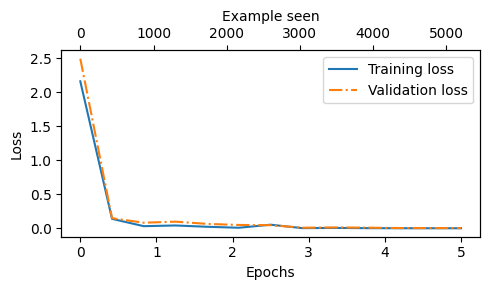

In [11]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

In [12]:
train_accuracy = calc_accuracy_loader(train_dl, model, device)
val_accuracy = calc_accuracy_loader(val_dl, model, device)
test_accuracy = calc_accuracy_loader(test_dl, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 100.00%
Validation accuracy: 98.66%
Test accuracy: 98.67%


## Exercise 6.3

Try fine-tuning the first output token. Notice the changes in predictive performance compared to fine-tuning the last output token.

In [13]:
# Rebuild the model
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

# Ensure all the parameters are not frozen
for p in model.parameters():
  p.requires_grad = False

model.out_head = nn.Linear(
    BASE_CONFIG['emb_dim'],
    num_classes
)

# Fine tune classification head
for p in model.out_head.parameters():
  p.requires_grad = True

# Fine tune final layer norm
for p in model.final_norm.parameters():
  p.requires_grad = True

# Fine tune last transformer block
for p in model.trf_blocks[-1].parameters():
  p.requires_grad = True


In [14]:
# Rebuild the whole dataset to only use the max length of the train_ds
train_ds = SpamDataset(
    csv_file='./train.csv',
    tokenizer=tokenizer,
    max_length=None,
)

val_ds = SpamDataset(
    csv_file='./validation.csv',
    tokenizer=tokenizer,
    max_length=train_ds.max_length,
)

test_ds = SpamDataset(
    csv_file='./test.csv',
    tokenizer=tokenizer,
    max_length=train_ds.max_length,
)

train_dl = DataLoader(
    dataset=train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_dl = DataLoader(
    dataset=val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    drop_last=False,
)

test_dl = DataLoader(
    dataset=test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    drop_last=False,
)

In [15]:
# Change the calc_loss_batch function to use the first token as predictor
def calc_loss_batch(input_batch, target_batch, model, device):
  model.eval();
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)
  logits = model(input_batch)[:, 0, :]
  loss = torch.nn.functional.cross_entropy(logits, target_batch)
  return loss


In [16]:
# Fine-tune the model on the first token

start_time = time.time()
torch.manual_seed(123)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5
model.to(device)

train_losses, val_losses, train_acc, val_acc, examples_seen = \
    train_classifier_simple(
        model=model,
        train_loader=train_dl,
        val_loader=val_dl,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs,
        eval_freq=50,
        eval_iter=5,
    )

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 6.553, Val loss 5.993
Ep 1 (Step 000050): Train loss 0.592, Val loss 0.594
Ep 1 (Step 000100): Train loss 0.352, Val loss 0.456
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 2 (Step 000150): Train loss 0.339, Val loss 0.312
Ep 2 (Step 000200): Train loss 0.189, Val loss 0.207
Ep 2 (Step 000250): Train loss 0.107, Val loss 0.180
Training accuracy: 92.50% | Validation accuracy: 92.50%
Ep 3 (Step 000300): Train loss 0.142, Val loss 0.205
Ep 3 (Step 000350): Train loss 0.065, Val loss 0.099
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 4 (Step 000400): Train loss 0.025, Val loss 0.162
Ep 4 (Step 000450): Train loss 0.104, Val loss 0.117
Ep 4 (Step 000500): Train loss 0.196, Val loss 0.099
Training accuracy: 100.00% | Validation accuracy: 95.00%
Ep 5 (Step 000550): Train loss 0.144, Val loss 0.132
Ep 5 (Step 000600): Train loss 0.029, Val loss 0.091
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 0.99 m

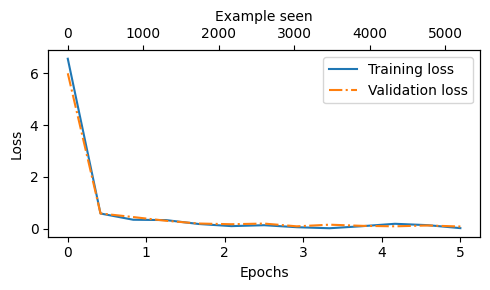

In [17]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

In [18]:
train_accuracy = calc_accuracy_loader(train_dl, model, device)
val_accuracy = calc_accuracy_loader(val_dl, model, device)
test_accuracy = calc_accuracy_loader(test_dl, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.40%
Validation accuracy: 97.32%
Test accuracy: 95.67%
